Imports

In [44]:
import re
import matplotlib.pyplot as plt
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sentence_transformers import SentenceTransformer
from kneed import KneeLocator


Helper functions

In [45]:
def estimate_threshold(Z):
    distances = Z[:, 2]
    kneedle = KneeLocator(range(len(distances)), distances, S=1.0, curve="concave", direction="increasing")
    return distances[kneedle.knee]

Extract Questions

In [37]:
cq_path = "competency_questions_all_documents.txt"

with open(cq_path, "r", encoding="utf-8") as f:
    content = f.read()

# Extract all questions from the file
questions = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.|\Z)', content, re.DOTALL)


Clustering and Plotting Function

In [38]:
# This was/is an experiment to implement BERTopic for clustering but i failed, good luck to the next one.
def cluster_and_plot_cq2(distances, model, questions, doc_vectors, method='ward', distance_threshold=1):
    """
    Plot a dendrogram based on the given distance matrix and optionally extract topics using BERTopic.
    
    Parameters:
    - model: Name of the vectorization model (e.g., "TF-IDF" or "SentenceTransformer").
    - method: Linkage method for hierarchical clustering (default: 'ward').
    - questions: List of questions.
    - embeddings: Embeddings for questions.
    """
    
    print(f"\nExtracting topics using BERTopic for {model}...")
    topic_model = BERTopic()
    topics, probs = topic_model.fit_transform(questions, doc_vectors)

    # Combine topics with questions for dendrogram labels
    labeled_questions = [
        f"Topic {topic}: {question}" for topic, question in zip(topics, questions)
    ]
    
    # Perform hierarchical clustering
    Z = linkage(distances, method=method)

    cluster_labels = fcluster(Z, t=distance_threshold, criterion='distance')

    # Print clusters
    print("\nClusters:")
    for cluster_id in set(cluster_labels):
        print(f"Cluster {cluster_id}:")
        for i, label in enumerate(cluster_labels):
            if label == cluster_id:
                print(f"  - {questions[i]}")

    # Create a dendrogram with labeled questions
    plt.figure(figsize=(12, 8))
    dendrogram(
        Z,
        labels=labeled_questions,
        leaf_rotation=90,
        color_threshold=distance_threshold,  # Hide splits below this distance
    )
    plt.title(f"Dendrogram of Competency Questions with {model} Vectorization")
    plt.xlabel("Questions (with Topics)")
    plt.ylabel("Distance")
    plt.legend()
    plt.show()


In [ ]:
def cluster_and_plot_cq(distances, model, method='ward', distance_threshold=False):
    """
    Plot a dendrogram based on the given distance matrix. and return clustered questions.
    """
    Z = linkage(distances, method=method)

    if distance_threshold is False:
        # Estimate the distance threshold using the knee method
        distance_threshold = estimate_threshold(Z)
        print(f"Estimated distance threshold: {distance_threshold}")

    cluster_labels = fcluster(Z, t=distance_threshold, criterion='distance')

    clustered_questions = {}
    for cluster_id, question in zip(cluster_labels, questions):
        if cluster_id not in clustered_questions:
            clustered_questions[cluster_id] = []
        clustered_questions[cluster_id].append(question)

    # Create a dendrogram
    plt.figure(figsize=(10, 7))
    dendrogram(
        Z,
        labels=questions,
        leaf_rotation=90,
        color_threshold=distance_threshold)
    plt.title(f"Dendrogram of Competency Questions with {model} Vectorization")
    plt.xlabel("Questions")
    plt.ylabel("Distance")
    plt.show()

    return clustered_questions


TF-IDF-Vektorisierung

Estimated distance threshold: 0.6194680374185552


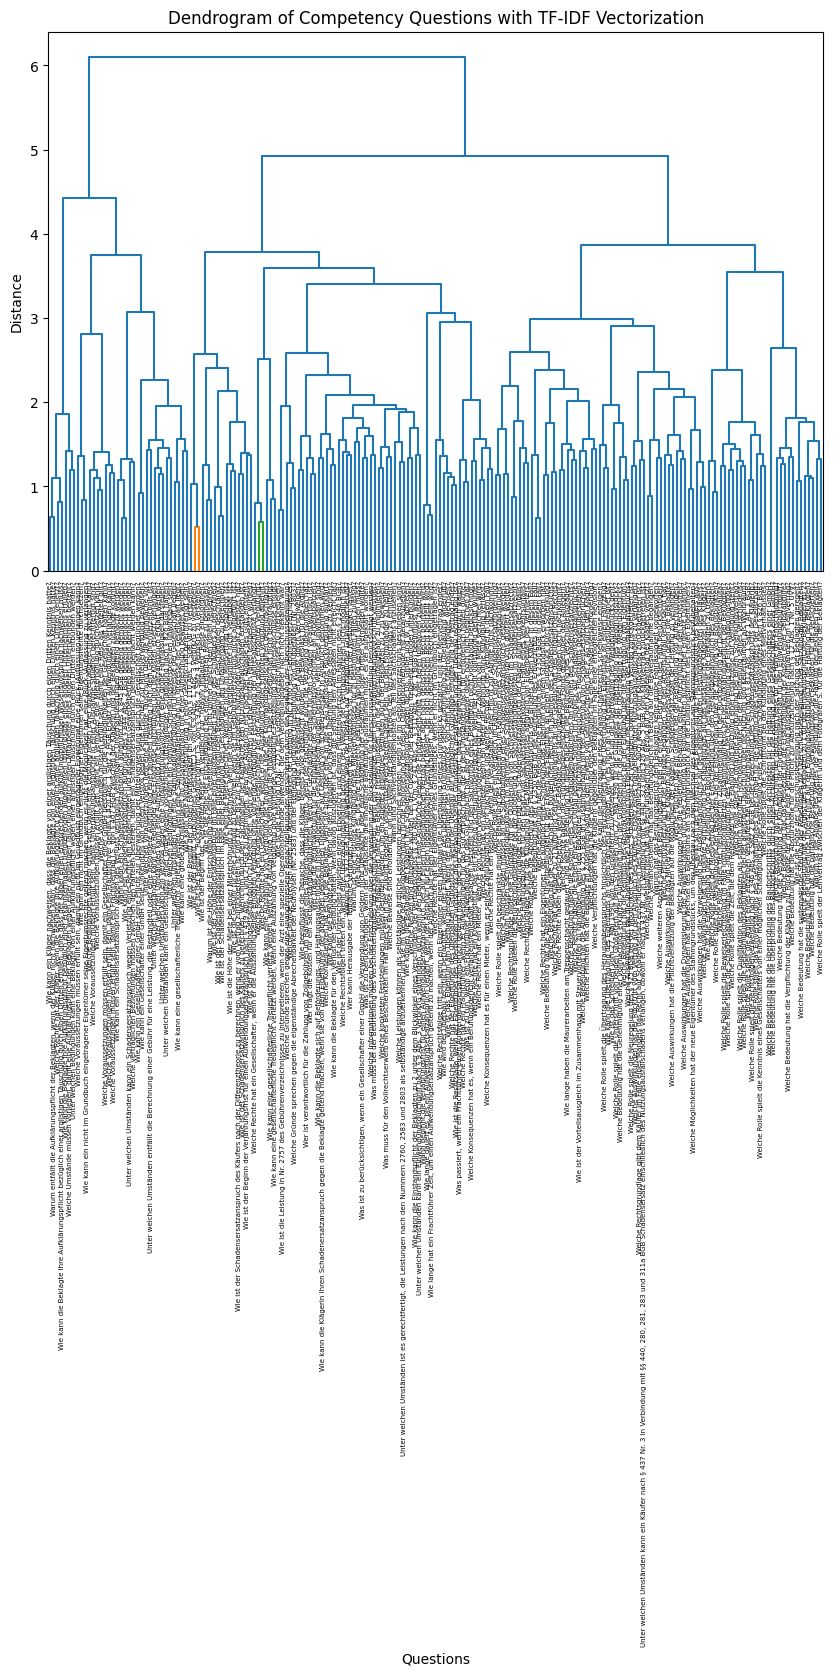

In [47]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(questions)

distances = pdist(X.toarray(), metric="cosine")

#cluster_and_plot_cq2(distances, model="TF-IDF", questions=questions, doc_vectors=X.toarray())
clustered_cq_TF = cluster_and_plot_cq(squareform(distances), "TF-IDF", method='ward')

Sentence Embedding Vertorisierung

Estimated distance threshold: 0.09132431752622638


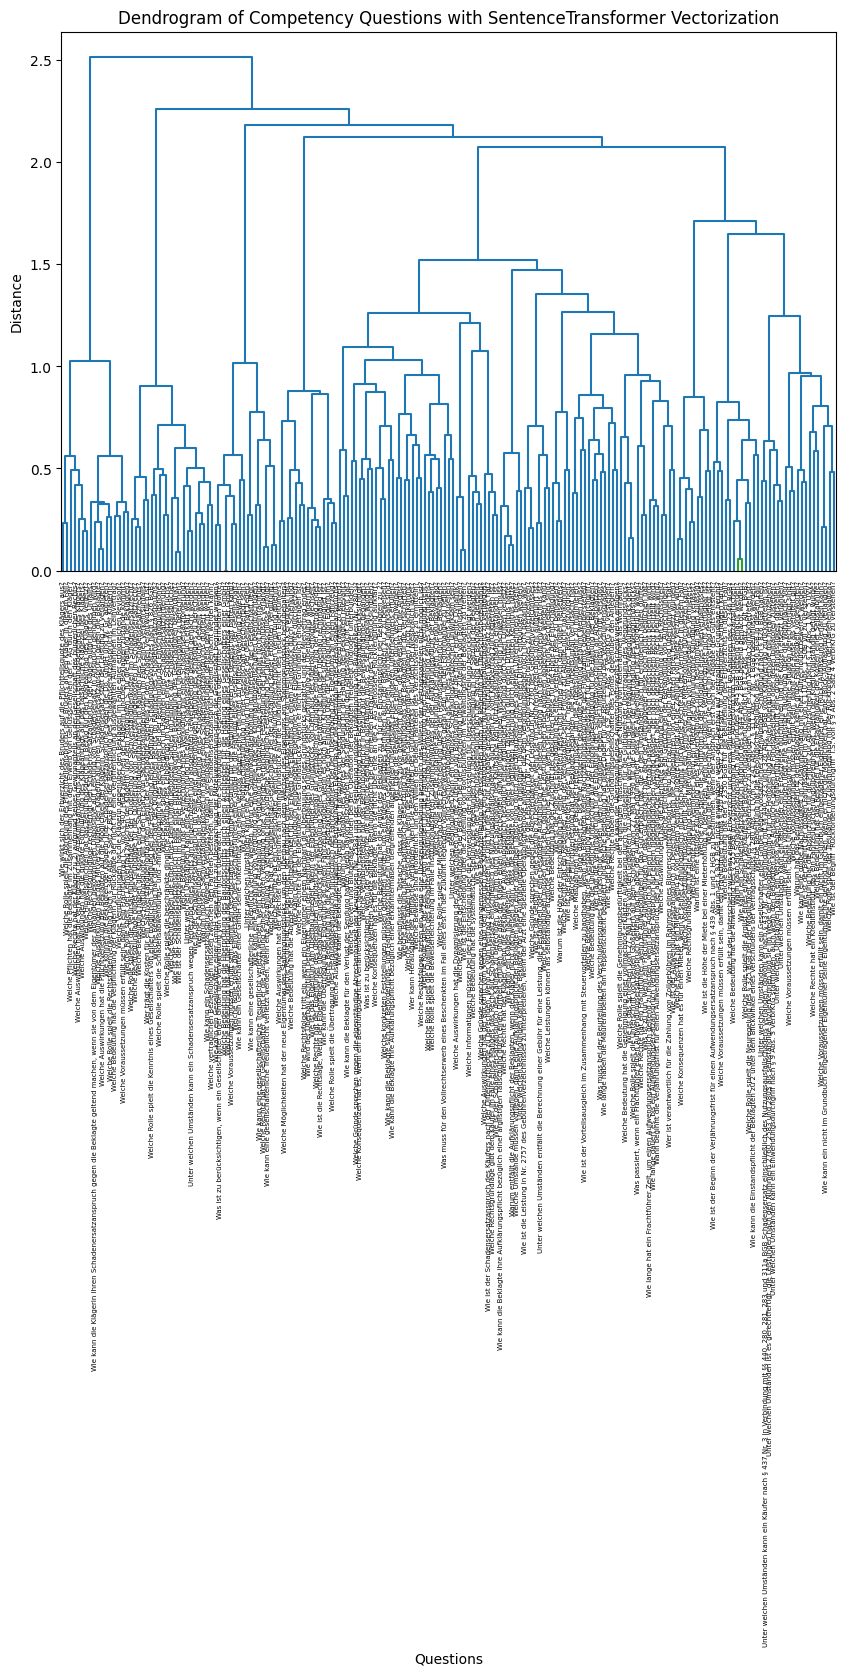

{np.int32(187): ['Welche Voraussetzungen müssen erfüllt sein, damit ein nicht im Grundbuch eingetragener Eigentümer eine (Rück-)Auflassung verlangen kann?'],
 np.int32(138): ['Wie ist das Schreiben vom 27. Mai 1990 von den Großeltern zu verstehen, wenn es um die Übertragung des Weggrundstücks geht?'],
 np.int32(139): ['Welche Rolle spielt die Unterschrift von beiden Großeltern auf dem Schreiben vom 27. Mai 1990 für die Gültigkeit der Übertragung des Weggrundstücks?'],
 np.int32(57): ['Welche Rechte hat der Eigentümer eines Grundstücks, wenn er nicht im Grundbuch eingetragen ist?'],
 np.int32(59): ['Wie kann ein nicht im Grundbuch eingetragener Eigentümer seine Eigentumsrechte durchsetzen?'],
 np.int32(140): ['Welche Bedeutung hat die Genehmigung einer vollmachtlos erklärten Auflassung durch die Großeltern für die Gültigkeit der Übertragung des Weggrundstücks?'],
 np.int32(188): ['Wie kann ein nicht im Grundbuch eingetragener Eigentümer seine Eigentumsrechte geltend machen, wenn er nich

In [48]:
modelST = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = modelST.encode(questions)

distances = pdist(embeddings, metric="cosine")

#cluster_and_plot_cq2(distances, model="Sentence Embeddings", questions=questions, doc_vectors=embeddings)
cluster_and_plot_cq(distances, "SentenceTransformer", method='ward')
